In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('Data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
print("Dataset Info:")
print(df.info())
 
print("\nMissing Values:")
print(df.isnull().sum())
 
print("\nAttrition Value Counts:")
print(df['Attrition'].value_counts())
 
print("\nAttrition %:")
print(df['Attrition'].value_counts(normalize=True) * 100)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel  

In [5]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


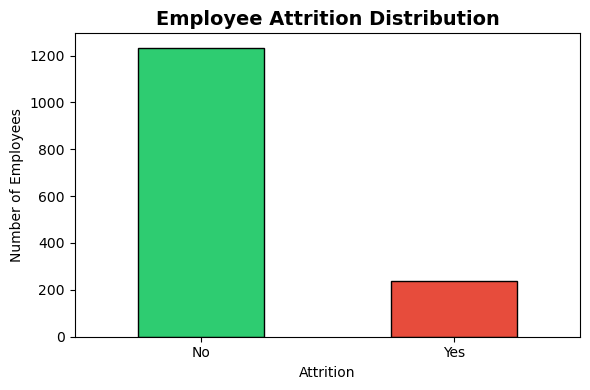

Total Employees: 1470
Employees Left: 237
Attrition Rate: 16.12%


In [6]:
plt.figure(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
df['Attrition'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Total Employees: {len(df)}")
print(f"Employees Left: {df['Attrition'].value_counts()['Yes']}")
print(f"Attrition Rate: {df['Attrition'].value_counts(normalize=True)['Yes']*100:.2f}%")

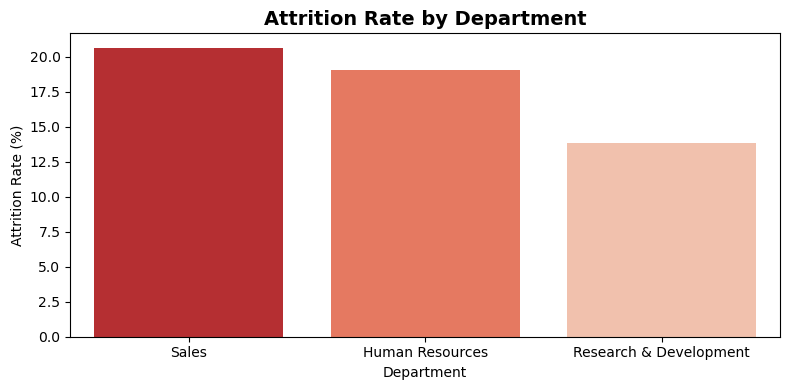

               Department  Attrition Rate (%)
2                   Sales           20.627803
0         Human Resources           19.047619
1  Research & Development           13.839750


In [7]:
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
dept_attrition.columns = ['Department', 'Attrition Rate (%)']
dept_attrition = dept_attrition.sort_values('Attrition Rate (%)', ascending=False)
 
plt.figure(figsize=(8, 4))
sns.barplot(data=dept_attrition, x='Department', y='Attrition Rate (%)', palette='Reds_r')
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('attrition_by_department.png', dpi=150, bbox_inches='tight')
plt.show()
print(dept_attrition)

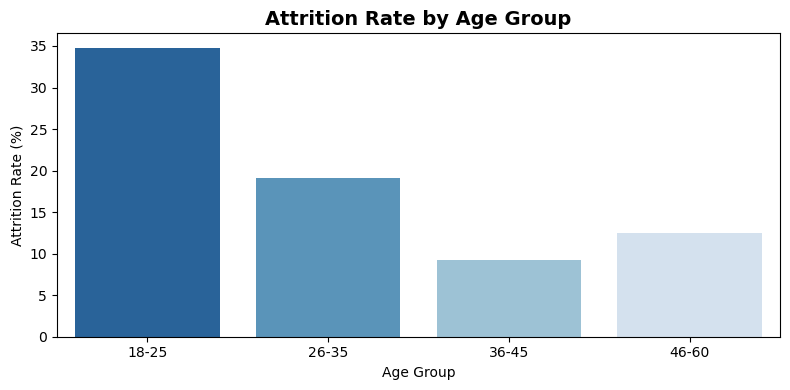

  Age Group  Attrition Rate (%)
0     18-25           34.782609
1     26-35           19.141914
2     36-45            9.188034
3     46-60           12.454212


In [8]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 60],
                         labels=['18-25', '26-35', '36-45', '46-60'])
 
age_attrition = df.groupby('AgeGroup')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
age_attrition.columns = ['Age Group', 'Attrition Rate (%)']
 
plt.figure(figsize=(8, 4))
sns.barplot(data=age_attrition, x='Age Group', y='Attrition Rate (%)', palette='Blues_r')
plt.title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('attrition_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print(age_attrition)

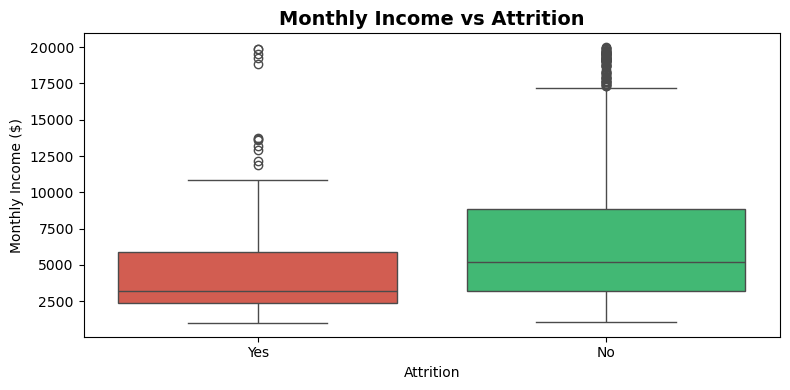

Avg Income - Employees who Left: 4787.09
Avg Income - Employees who Stayed: 6832.74


In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
plt.title('Monthly Income vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income ($)')
plt.tight_layout()
plt.savefig('income_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("Avg Income - Employees who Left:", df[df['Attrition']=='Yes']['MonthlyIncome'].mean().round(2))
print("Avg Income - Employees who Stayed:", df[df['Attrition']=='No']['MonthlyIncome'].mean().round(2))

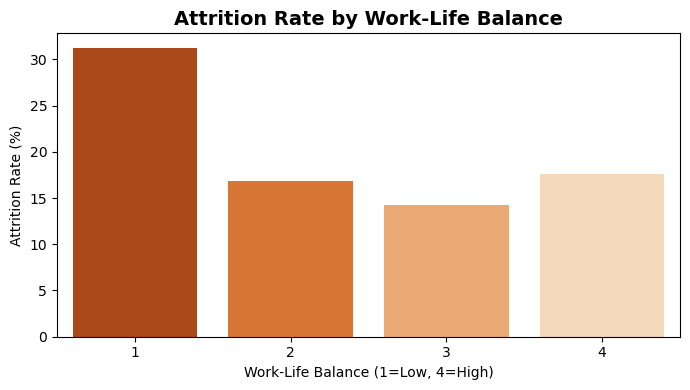

   Work-Life Balance  Attrition Rate (%)
0                  1           31.250000
1                  2           16.860465
2                  3           14.221725
3                  4           17.647059


In [10]:
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
wlb_attrition.columns = ['Work-Life Balance', 'Attrition Rate (%)']
 
plt.figure(figsize=(7, 4))
sns.barplot(data=wlb_attrition, x='Work-Life Balance', y='Attrition Rate (%)', palette='Oranges_r')
plt.title('Attrition Rate by Work-Life Balance', fontsize=14, fontweight='bold')
plt.xlabel('Work-Life Balance (1=Low, 4=High)')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('worklife_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print(wlb_attrition)

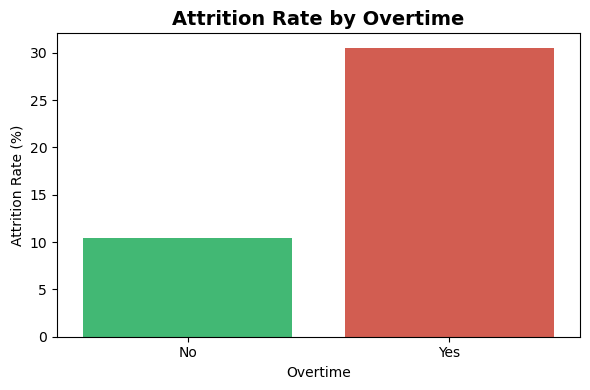

  OverTime  Attrition Rate (%)
0       No           10.436433
1      Yes           30.528846


In [11]:
ot_attrition = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
ot_attrition.columns = ['OverTime', 'Attrition Rate (%)']
 
plt.figure(figsize=(6, 4))
sns.barplot(data=ot_attrition, x='OverTime', y='Attrition Rate (%)',
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
plt.title('Attrition Rate by Overtime', fontsize=14, fontweight='bold')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('overtime_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print(ot_attrition)

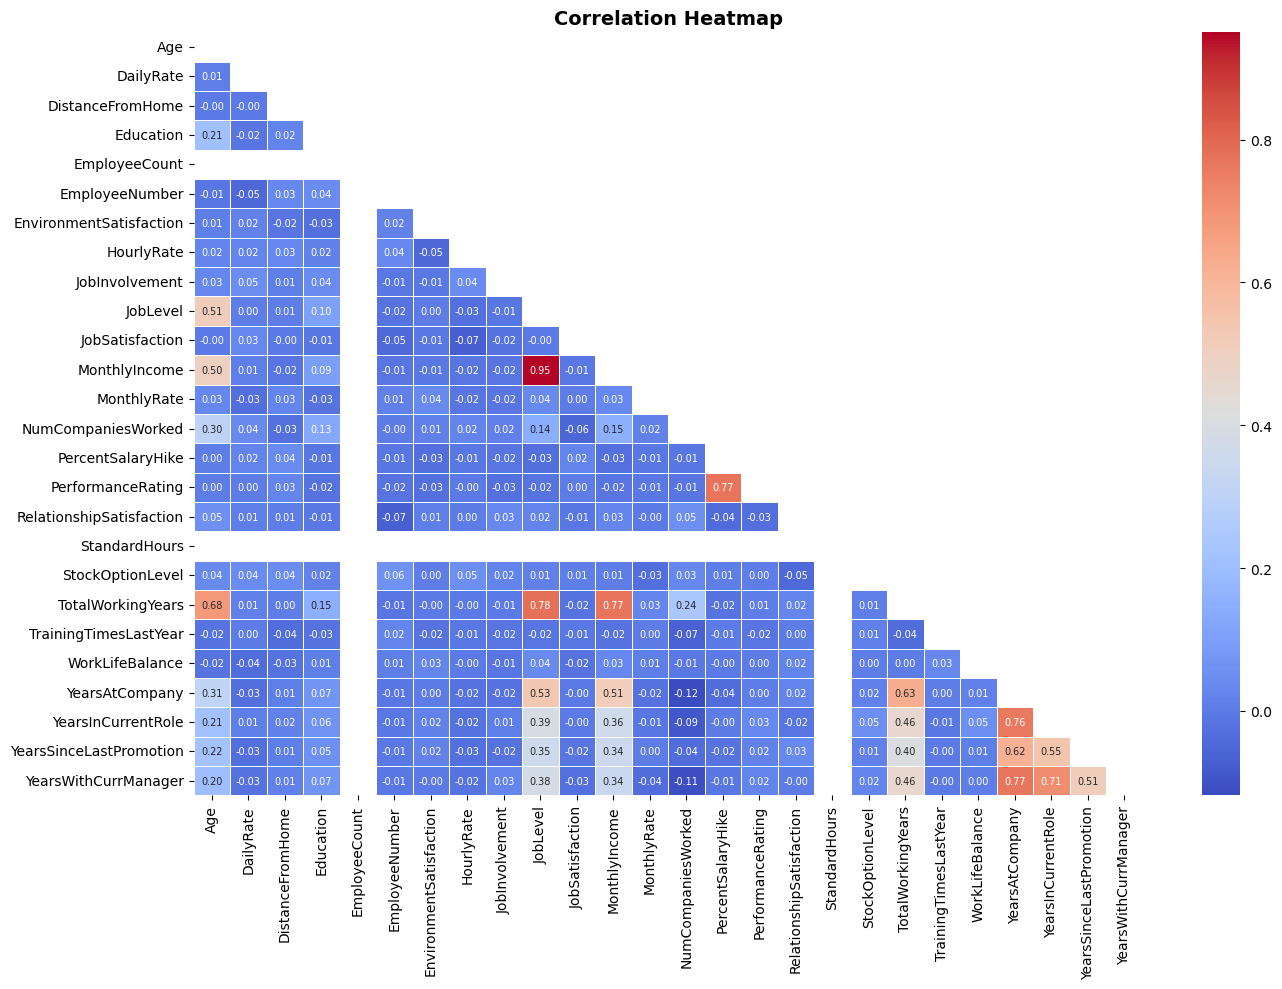

In [12]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 7})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
df_ml = df.copy()
 
# Drop unnecessary columns
df_ml.drop(['EmployeeCount', 'EmployeeNumber', 'Over18',
            'StandardHours', 'AgeGroup'], axis=1, inplace=True)
 
# Encode categorical columns
le = LabelEncoder()
categorical_cols = df_ml.select_dtypes(include=['object']).columns.tolist()
 
for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])
 
print("Categorical columns encoded:", categorical_cols)
print("Shape after preprocessing:", df_ml.shape)
df_ml.head()

Categorical columns encoded: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after preprocessing: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [14]:
X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1176, 30)
Testing set size: (294, 30)


In [16]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
 
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
 
print(f"Model Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

Model Accuracy: 84.35%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.86      0.98      0.91       247
        Left       0.55      0.13      0.21        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.56       294
weighted avg       0.81      0.84      0.80       294



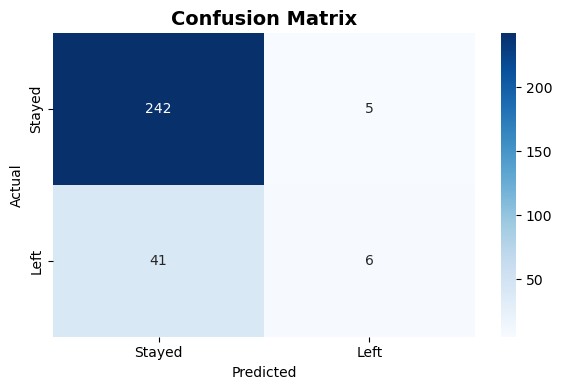

In [17]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

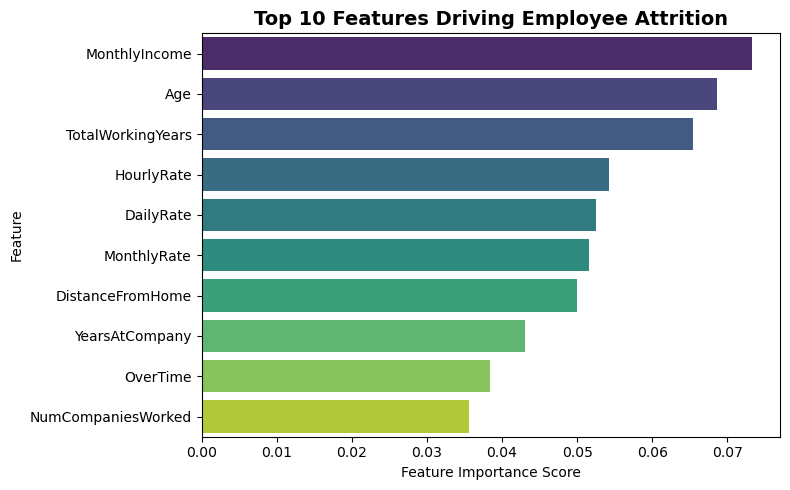

Top 10 Features:
               Feature  Importance
15       MonthlyIncome    0.073336
0                  Age    0.068557
23   TotalWorkingYears    0.065480
9           HourlyRate    0.054217
2            DailyRate    0.052526
16         MonthlyRate    0.051631
4     DistanceFromHome    0.049930
26      YearsAtCompany    0.043107
18            OverTime    0.038350
17  NumCompaniesWorked    0.035546


In [18]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
 
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Features Driving Employee Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("Top 10 Features:")
print(feature_importance)

In [19]:
print("=" * 50)
print("KEY INSIGHTS — HR ATTRITION ANALYSIS")
print("=" * 50)
 
attrition_rate = df['Attrition'].value_counts(normalize=True)['Yes'] * 100
avg_income_left = df[df['Attrition']=='Yes']['MonthlyIncome'].mean()
avg_income_stayed = df[df['Attrition']=='No']['MonthlyIncome'].mean()
ot_yes = df[df['OverTime']=='Yes']['Attrition'].value_counts(normalize=True)['Yes'] * 100
ot_no = df[df['OverTime']=='No']['Attrition'].value_counts(normalize=True)['Yes'] * 100
 
print(f"\n1. Overall Attrition Rate: {attrition_rate:.2f}%")
print(f"2. Avg Monthly Income (Left): ${avg_income_left:.2f}")
print(f"3. Avg Monthly Income (Stayed): ${avg_income_stayed:.2f}")
print(f"4. Attrition Rate WITH Overtime: {ot_yes:.2f}%")
print(f"5. Attrition Rate WITHOUT Overtime: {ot_no:.2f}%")
print(f"6. Model Accuracy: {accuracy*100:.2f}%")
print(f"7. Top Factor: {feature_importance.iloc[0]['Feature']}")
print("=" * 50)

KEY INSIGHTS — HR ATTRITION ANALYSIS

1. Overall Attrition Rate: 16.12%
2. Avg Monthly Income (Left): $4787.09
3. Avg Monthly Income (Stayed): $6832.74
4. Attrition Rate WITH Overtime: 30.53%
5. Attrition Rate WITHOUT Overtime: 10.44%
6. Model Accuracy: 84.35%
7. Top Factor: MonthlyIncome
